# Model Evaluation

author: Branden Chen, Yale Tsai

## Set Up

In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from src import *

## Baseline Model

Loading data...

Basic dataset summary
--------------------------------------------------
Rows: 7,860
Unique prompts: 240
Unique models: 33

Prompts by dataset:
dataset
AIME        60
GPQA        60
LCB         60
MMLU-Pro    60
Name: count, dtype: int64

Weighting scheme
--------------------------------------------------
Total prompt weight = 1.000000

Solving for alpha = 0.01
Using solver: appsi_highs
  Oracle Routing            -> cost=0.000163, score=0.958333
  Single Best                -> cost=0.000000, score=0.616667, model=MiniCPM4.1-8B
  Single Best per Benchmark  -> cost=0.000665, score=0.750000

Solving for alpha = 0.05
Using solver: appsi_highs
  Oracle Routing            -> cost=0.000595, score=0.970833
  Single Best                -> cost=0.001756, score=0.729167, model=qwen3-235b-a22b-2507
  Single Best per Benchmark  -> cost=0.001733, score=0.816667

Solving for alpha = 0.1
Using solver: appsi_highs
  Oracle Routing            -> cost=0.001222, score=0.979167
  Single B

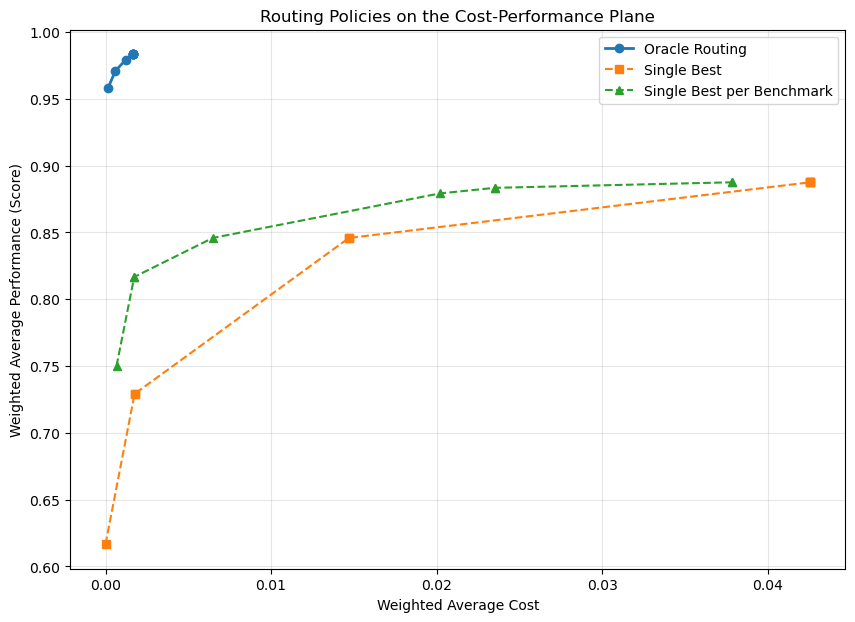


Saved outputs:
  ../data/baseline_outputs/policy_summary.csv
  ../data/baseline_outputs/cost_performance_frontier.png
  ../data/baseline_outputs


In [2]:
load_baseline_model()

---

## Optimization Model

### Problem Description

We model LLM routing as a **two-stage stochastic mixed-integer program**.

- **Stage 1** (strategic): Before observing any prompt, select a pool of at most $K$ models from the full candidate set $\mathcal{M}$.  This captures real-world engineering constraints—companies limit model pool size to control maintenance overhead.

- **Stage 2** (operational): After observing each prompt, route it to the best available model in the selected pool.

The stochastic element arises from prompt uncertainty: prompts are treated as random draws from an unknown distribution $\mathcal{P}$.  We approximate this distribution via **Sample Average Approximation (SAA)** using the empirical dataset, with weights $w_p$ that can be tuned to reflect different company focus areas.

### Notation

| Symbol | Type | Description |
|--------|------|-------------|
| $\mathcal{P}$ | Set | All prompts, $\lvert\mathcal{P}\rvert = 240$ |
| $\mathcal{M}$ | Set | All candidate models, $\lvert\mathcal{M}\rvert = 33$ |
| $\mathcal{D}$ | Set | Benchmark datasets $\{\text{AIME, GPQA, LCB, MMLU-Pro}\}$ |
| $\mathcal{P}_d$ | Set | Prompts from dataset $d \in \mathcal{D}$ |
| $s_{pm} \in \{0,1\}$ | Parameter | Performance score of model $m$ on prompt $p$ |
| $c_{pm} \geq 0$ | Parameter | Cost (\$) of model $m$ on prompt $p$ |
| $w_p \geq 0,\ \sum_p w_p = 1$ | Parameter | SAA prompt weight (approximates prompt arrival probability) |
| $K \in \mathbb{Z}_{+}$ | **Hyperparameter** | Maximum pool size |
| $B \geq 0$ | **Hyperparameter** | Budget — max weighted-average cost per prompt |
| $Q_d \in [0,1]$ | **Hyperparameter** | Minimum required avg score on dataset $d$ |
| $\lambda \geq 0$ | **Hyperparameter** | Penalty per unit of quality-constraint violation |
| $y_m \in \{0,1\}$ | **Stage-1 variable** | 1 if model $m$ is selected into the pool |
| $x_{pm} \in \{0,1\}$ | **Stage-2 variable** | 1 if prompt $p$ is routed to model $m$ |
| $\text{slack}_d \geq 0$ | **Aux variable** | Quality violation slack for dataset $d$ |

### Formulation

$$
\max_{y, x, \text{slack}} \quad \sum_{p \in \mathcal{P}} w_p \sum_{m \in \mathcal{M}} s_{pm}\, x_{pm} \;-\; \lambda \sum_{d \in \mathcal{D}} \text{slack}_d
$$

subject to:

$$
\begin{aligned}
&\textbf{(1) Pool size:} & \sum_{m \in \mathcal{M}} y_m &\leq K \\[6pt]
&\textbf{(2) Assignment:} & \sum_{m \in \mathcal{M}} x_{pm} &= 1 \qquad \forall\, p \in \mathcal{P} \\[6pt]
&\textbf{(3) Routing linkage:} & x_{pm} &\leq y_m \qquad \forall\, p \in \mathcal{P},\ m \in \mathcal{M} \\[6pt]
&\textbf{(4) Budget:} & \sum_{p \in \mathcal{P}} w_p \sum_{m \in \mathcal{M}} c_{pm}\, x_{pm} &\leq B \\[6pt]
&\textbf{(5) Quality guarantee (soft):} & \frac{1}{|\mathcal{P}_d|} \sum_{p \in \mathcal{P}_d} \sum_{m \in \mathcal{M}} s_{pm}\, x_{pm} &\geq Q_d - \text{slack}_d \qquad \forall\, d \in \mathcal{D} \\[6pt]
&\textbf{(6) Integrality:} & y_m \in \{0,1\},\ x_{pm} \in \{0,1\},\ \text{slack}_d &\geq 0
\end{aligned}
$$

**Coupling constraint (3)** is the key two-stage linkage: Stage-2 routing decisions $x_{pm}$ are constrained by Stage-1 pool decisions $y_m$.  This creates a MILP that jointly optimises pool selection and routing policy.

**Soft quality guarantee (5)** allows infeasibility (via slack) to ensure the solver always finds a solution, but penalises violations in the objective via $\lambda$.

### SAA Interpretation of Prompt Weights

The SAA weight $w_p$ approximates $\Pr(\text{next prompt} = p)$ under a company's operating distribution.  We model three scenarios:

| Scenario | Dataset multipliers | Represents |
|----------|--------------------|-|
| Balanced | all × 1 | General-purpose assistant |
| Coding-focused | LCB × 4 | Coding IDE (e.g. Cursor) |
| Math-focused | AIME × 4 | Math tutoring platform |
| Knowledge-focused | GPQA × 3, MMLU-Pro × 3 | Research / QA assistant |

Different $w_p$ yield different optimal pools, revealing which models are domain specialists vs. generalists.

---

## Q1: How large must the model pool be? (Pool Size vs. Performance)

We sweep $K = 1, 2, \ldots, 10$ under a fixed budget $B$ and record the optimal weighted average score.
The resulting curve reveals whether there are **diminishing marginal returns** to increasing pool size.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Hyperparameters ────────────────────────────────────────────────────────
CSV_PATH     = "../data/routerbench.csv"
K_VALUES     = list(range(1, 11))   # pool sizes to sweep
BUDGET       = 0.01                 # max weighted-average cost per prompt ($)
SLACK_PENALTY = 10.0                # λ: penalty per unit quality violation

# Optional per-dataset minimum quality (set to {} to disable)
Q_MIN = {}
# Example: Q_MIN = {'LCB': 0.60, 'AIME': 0.40}
# ──────────────────────────────────────────────────────────────────────────

df = load_routerbench_data(CSV_PATH)

# Uniform weights for Q1 (balanced company)
weights_uniform = build_weighted_prompt_weights(df)

print("=== Q1: Pool Size Sweep ===")
q1_df = sweep_pool_size(
    df,
    prompt_weights   = weights_uniform,
    K_values         = K_VALUES,
    B                = BUDGET,
    Q_min_by_dataset = Q_MIN,
    slack_penalty    = SLACK_PENALTY,
)

q1_df[["K", "avg_score", "avg_cost", "n_selected"]]

=== Q1: Pool Size Sweep ===
  Solving K = 1 ...  Using solver: appsi_highs
avg_score = 0.7417,  avg_cost = 0.004704,  pool = ['gpt-5-chat']
  Solving K = 2 ...  Using solver: appsi_highs
avg_score = 0.9042,  avg_cost = 0.009975,  pool = ['deepseek-r1-0528', 'qwen3-235b-a22b-2507']
  Solving K = 3 ...  Using solver: appsi_highs
avg_score = 0.9500,  avg_cost = 0.010000,  pool = ['Qwen3-8B', 'gpt-5', 'kimi-k2-0905']
  Solving K = 4 ...  Using solver: appsi_highs
avg_score = 0.9667,  avg_cost = 0.009997,  pool = ['GLM-Z1-9B-0414', 'glm-4.6', 'gpt-5', 'kimi-k2-0905']
  Solving K = 5 ...  Using solver: appsi_highs
avg_score = 0.9792,  avg_cost = 0.009966,  pool = ['GLM-Z1-9B-0414', 'Llama-3.1-8B-UltraMedical', 'glm-4.6', 'gpt-5', 'kimi-k2-0905']
  Solving K = 6 ...  Using solver: appsi_highs
avg_score = 0.9833,  avg_cost = 0.009714,  pool = ['GLM-Z1-9B-0414', 'Llama-3.1-8B-UltraMedical', 'gemini-2.5-flash', 'glm-4.6', 'gpt-5', 'kimi-k2-0905']
  Solving K = 7 ...  Using solver: appsi_highs
av

,K,avg_score,avg_cost,n_selected
0,1,0.741667,0.004704,1
1,2,0.904167,0.009975,2
2,3,0.950000,0.010000,3
3,4,0.966667,0.009997,4
4,5,0.979167,0.009966,5
5,6,0.983333,0.009714,6
6,7,0.983333,0.009620,7
7,8,0.983333,0.009989,7
8,9,0.983333,0.009856,8
9,10,0.983333,0.009922,9


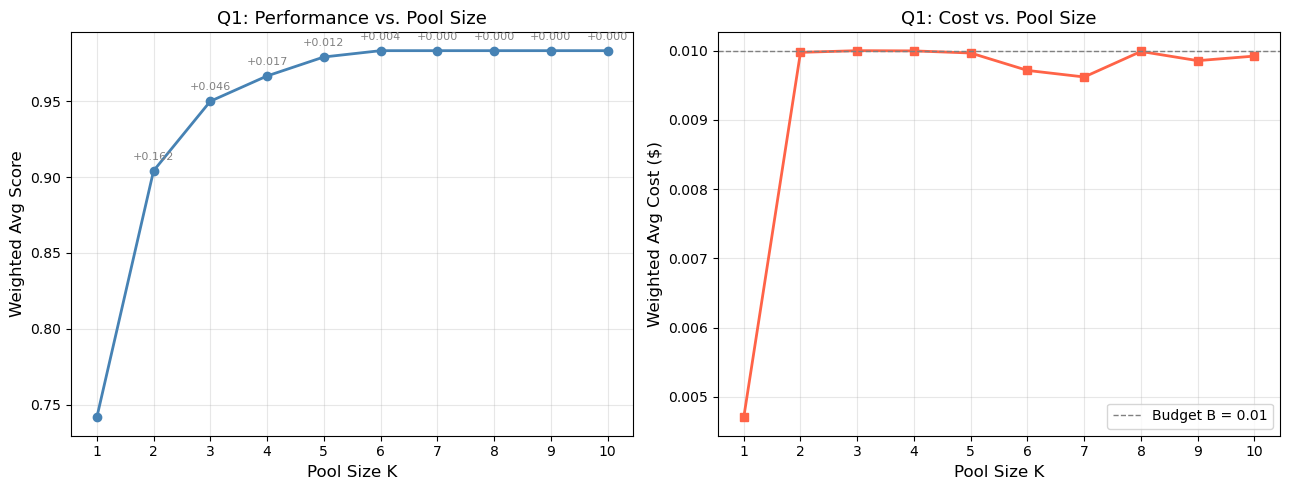

Saved: output/q1_pool_size_sweep.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: avg_score vs K
ax = axes[0]
ax.plot(q1_df["K"], q1_df["avg_score"], marker="o", linewidth=2, color="steelblue")
ax.set_xlabel("Pool Size K", fontsize=12)
ax.set_ylabel("Weighted Avg Score", fontsize=12)
ax.set_title("Q1: Performance vs. Pool Size", fontsize=13)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.grid(True, alpha=0.3)

# Annotate marginal gain
for i in range(1, len(q1_df)):
    gain = q1_df["avg_score"].iloc[i] - q1_df["avg_score"].iloc[i - 1]
    ax.annotate(
        f"+{gain:.3f}",
        (q1_df["K"].iloc[i], q1_df["avg_score"].iloc[i]),
        textcoords="offset points", xytext=(0, 8),
        fontsize=8, ha="center", color="gray",
    )

# Right: cost vs K
ax2 = axes[1]
ax2.plot(q1_df["K"], q1_df["avg_cost"], marker="s", linewidth=2, color="tomato")
ax2.axhline(BUDGET, linestyle="--", color="gray", linewidth=1, label=f"Budget B = {BUDGET}")
ax2.set_xlabel("Pool Size K", fontsize=12)
ax2.set_ylabel("Weighted Avg Cost ($)", fontsize=12)
ax2.set_title("Q1: Cost vs. Pool Size", fontsize=13)
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig("../output/q1_pool_size_sweep.png", dpi=180)
plt.show()
print("Saved: output/q1_pool_size_sweep.png")

---

## Q2: How Does the Optimal Pool Change Under Different Prompt Distributions?

We test **four weight scenarios** that represent different company focus areas.
Changing $w_p$ simulates distributional shift in the prompt arrival process (the SAA robustness analysis).

By comparing the selected model pools across scenarios, we can answer:
- Which models are **generalists** (always selected)?
- Which models are **domain specialists** (only selected under certain distributions)?
- How much does performance change when the routing policy is applied out-of-distribution?

In [5]:
# ── Hyperparameters ────────────────────────────────────────────────────────
K_Q2          = 5       # fixed pool size for Q2
BUDGET_Q2     = 0.01    # fixed budget for Q2
SLACK_PENALTY_Q2 = 10.0

# Define weight scenarios: {scenario name -> dataset multiplier dict}
# Datasets not listed receive multiplier = 1.0 (then all weights are normalised)
WEIGHT_SCENARIOS = {
    "Balanced":                    {},
    "Coding-focused (LCB ×4)":     {"LCB":    4.0},
    "Math-focused (AIME ×4)":      {"AIME":   4.0},
    "Knowledge-focused (×3)":      {"GPQA":   3.0, "MMLU-Pro": 3.0},
}
# ──────────────────────────────────────────────────────────────────────────

print("=== Q2: Prompt Weight Scenario Sweep ===")
q2_df = sweep_prompt_weights(
    df,
    weight_scenarios = WEIGHT_SCENARIOS,
    K                = K_Q2,
    B                = BUDGET_Q2,
    Q_min_by_dataset = Q_MIN,
    slack_penalty    = SLACK_PENALTY_Q2,
)

q2_df[["scenario", "avg_score", "avg_cost", "selected_models"]]

=== Q2: Prompt Weight Scenario Sweep ===
  Scenario: 'Balanced' ...  Using solver: appsi_highs
avg_score = 0.9792,  avg_cost = 0.009966
  Scenario: 'Coding-focused (LCB ×4)' ...  Using solver: appsi_highs
avg_score = 0.9881,  avg_cost = 0.009988
  Scenario: 'Math-focused (AIME ×4)' ...  Using solver: appsi_highs
avg_score = 0.9643,  avg_cost = 0.010000
  Scenario: 'Knowledge-focused (×3)' ...  Using solver: appsi_highs
avg_score = 0.9812,  avg_cost = 0.009961


,scenario,avg_score,avg_cost,selected_models
0,Balanced,0.979167,0.009966,"[GLM-Z1-9B-0414, Llama-3.1-8B-UltraMedical, gl..."
1,Coding-focused (LCB ×4),0.988095,0.009988,"[GLM-Z1-9B-0414, Llama-3.1-8B-UltraMedical, gl..."
2,Math-focused (AIME ×4),0.964286,0.010000,"[NVIDIA-Nemotron-Nano-9B-v2, gemini-2.5-flash,..."
3,Knowledge-focused (×3),0.981250,0.009961,"[GLM-Z1-9B-0414, Llama-3.1-8B-UltraMedical, gl..."


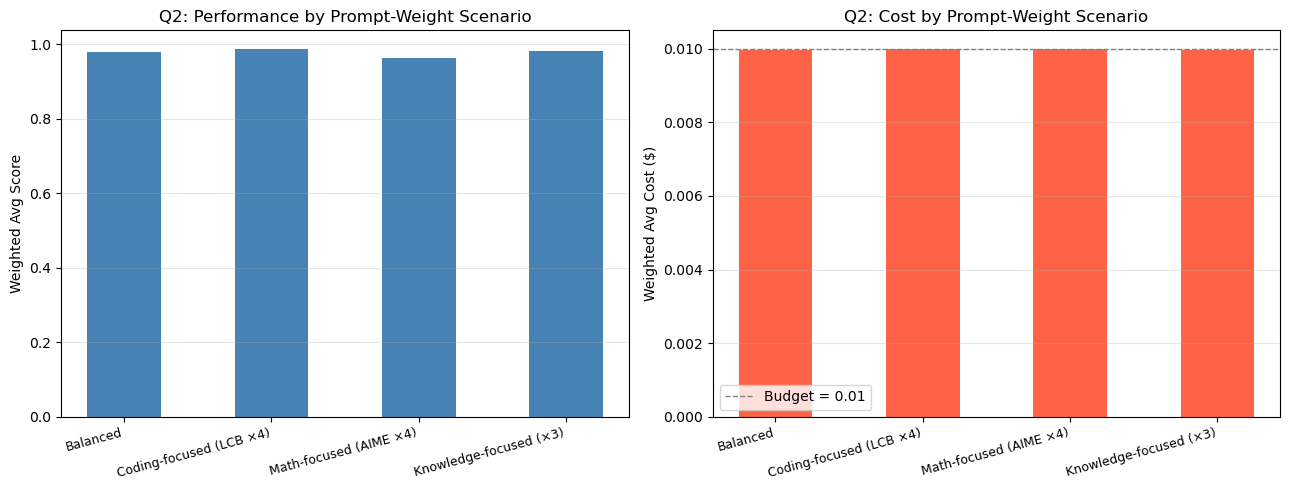

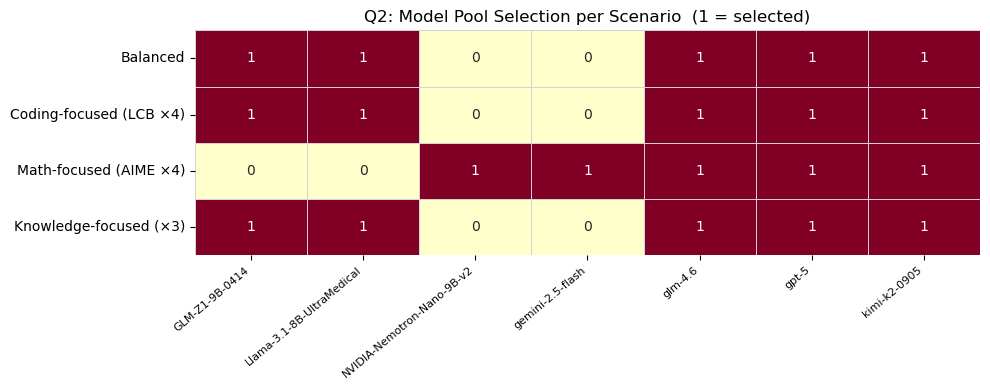

Saved: output/q2_scenario_bar.png, output/q2_model_heatmap.png


In [6]:
import numpy as np

scenarios   = q2_df["scenario"].tolist()
all_models  = sorted({m for pool in q2_df["selected_models"] for m in pool})

# ── Plot 1: Score & Cost bar chart per scenario ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(scenarios))
axes[0].bar(x, q2_df["avg_score"], color="steelblue", width=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(scenarios, rotation=15, ha="right", fontsize=9)
axes[0].set_ylabel("Weighted Avg Score")
axes[0].set_title("Q2: Performance by Prompt-Weight Scenario")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x, q2_df["avg_cost"], color="tomato", width=0.5)
axes[1].axhline(BUDGET_Q2, linestyle="--", color="gray", linewidth=1, label=f"Budget = {BUDGET_Q2}")
axes[1].set_xticks(x)
axes[1].set_xticklabels(scenarios, rotation=15, ha="right", fontsize=9)
axes[1].set_ylabel("Weighted Avg Cost ($)")
axes[1].set_title("Q2: Cost by Prompt-Weight Scenario")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("../output/q2_scenario_bar.png", dpi=180)
plt.show()

# ── Plot 2: Model selection heatmap ──────────────────────────────────────
import seaborn as sns

heat = pd.DataFrame(
    [[1 if m in pool else 0 for m in all_models]
     for pool in q2_df["selected_models"]],
    index=scenarios,
    columns=all_models,
)

fig, ax = plt.subplots(figsize=(max(10, len(all_models) * 0.7), 4))
sns.heatmap(
    heat, ax=ax,
    cmap="YlOrRd", linewidths=0.5, linecolor="lightgray",
    cbar=False, annot=True, fmt="d",
)
ax.set_title("Q2: Model Pool Selection per Scenario  (1 = selected)", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("../output/q2_model_heatmap.png", dpi=180)
plt.show()
print("Saved: output/q2_scenario_bar.png, output/q2_model_heatmap.png")

---

## Q2 Extension: Pure Specialization & Cross-Domain Robustness

In Q2 we used *emphasis* weights (e.g. LCB ×4). Here we go to the extreme:
each scenario sets **one dataset's weight = 1 and all others = 0**.

This answers two additional questions:

1. **What is the theoretical best pool for each domain?** (in-distribution upper bound)
2. **How badly does a specialised pool fail on other domains?** (out-of-distribution degradation)

The 4×4 cross-domain heatmap visualises both: the **diagonal** = in-distribution performance; the **off-diagonal** = out-of-distribution fragility.  A robust pool should have high values across the entire row, not just on the diagonal.

In [7]:
# ── Hyperparameters ────────────────────────────────────────────────────────
K_PURE        = 5
BUDGET_PURE   = 0.01
SLACK_PENALTY_PURE = 10.0

# Pure specialization: only one dataset has positive weight
PURE_SCENARIOS = {
    "AIME only":     {"AIME": 1,     "GPQA": 0, "LCB": 0, "MMLU-Pro": 0},
    "LCB only":      {"LCB":  1,     "AIME": 0, "GPQA": 0, "MMLU-Pro": 0},
    "GPQA only":     {"GPQA": 1,     "AIME": 0, "LCB": 0,  "MMLU-Pro": 0},
    "MMLU-Pro only": {"MMLU-Pro": 1, "AIME": 0, "GPQA": 0, "LCB": 0},
}
# ──────────────────────────────────────────────────────────────────────────

print("=== Pure Specialization Sweep ===")
pure_df = sweep_prompt_weights(
    df,
    weight_scenarios = PURE_SCENARIOS,
    K                = K_PURE,
    B                = BUDGET_PURE,
    slack_penalty    = SLACK_PENALTY_PURE,
)

pure_df[["scenario", "avg_score", "avg_cost", "selected_models"]]

=== Pure Specialization Sweep ===
  Scenario: 'AIME only' ...  Using solver: appsi_highs
avg_score = 0.9667,  avg_cost = 0.009791
  Scenario: 'LCB only' ...  Using solver: appsi_highs
avg_score = 1.0000,  avg_cost = 0.009992
  Scenario: 'GPQA only' ...  Using solver: appsi_highs
avg_score = 1.0000,  avg_cost = 0.009791
  Scenario: 'MMLU-Pro only' ...  Using solver: appsi_highs
avg_score = 0.9667,  avg_cost = 0.009914


,scenario,avg_score,avg_cost,selected_models
0,AIME only,0.966667,0.009791,"[GLM-Z1-9B-0414, Qwen3-8B, gemini-2.5-flash, g..."
1,LCB only,1.000000,0.009992,"[GLM-Z1-9B-0414, deepseek-r1-0528, deepseek-v3..."
2,GPQA only,1.000000,0.009791,"[MiniCPM4.1-8B, OpenThinker3-7B, Qwen2.5-Coder..."
3,MMLU-Pro only,0.966667,0.009914,"[Llama-3.1-8B-UltraMedical, Llama-3.1-Nemotron..."


Cross-domain performance matrix:
                AIME   GPQA    LCB  MMLU-Pro
optimised_for                               
AIME           0.967  0.900  0.967     0.900
GPQA           0.917  1.000  0.983     0.917
LCB            0.933  0.950  1.000     0.917
MMLU-Pro       0.883  0.983  0.900     0.967


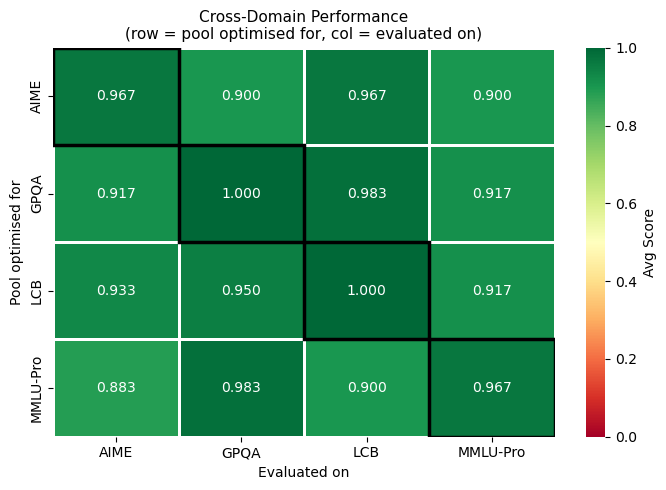

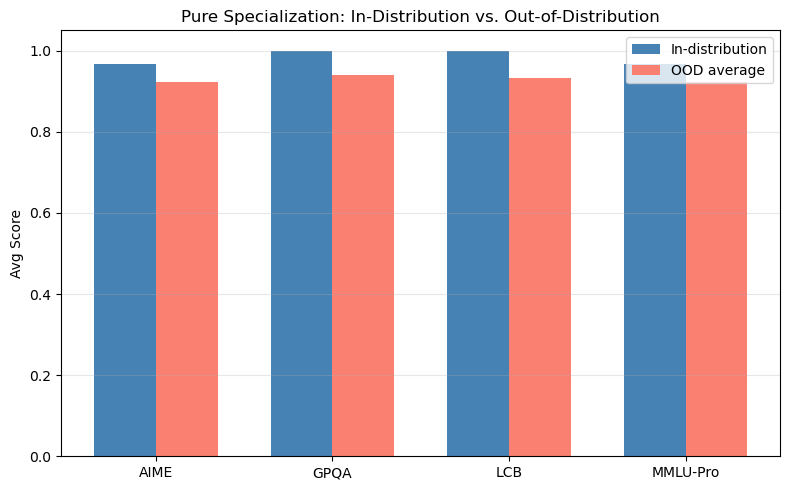

Saved: output/q2_cross_domain_heatmap.png, output/q2_ood_comparison.png


In [8]:
import seaborn as sns
import numpy as np

# Build {dataset -> pool} mapping from pure_df
dataset_labels = ["AIME only", "LCB only", "GPQA only", "MMLU-Pro only"]
pure_pools = {
    row["scenario"].replace(" only", ""): row["selected_models"]
    for _, row in pure_df.iterrows()
}

# Cross-domain matrix: rows = optimised-for, columns = evaluated-on
cross_mat = cross_domain_matrix(df, pure_pools)
print("Cross-domain performance matrix:")
print(cross_mat.round(3))

# ── Plot 1: Cross-domain heatmap ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

mask_diag = np.eye(len(cross_mat), dtype=bool)   # highlight diagonal

sns.heatmap(
    cross_mat, ax=ax,
    cmap="RdYlGn", vmin=0, vmax=1,
    annot=True, fmt=".3f", linewidths=0.8,
    cbar_kws={"label": "Avg Score"},
)

# Bold the diagonal cells with a rectangle
for i in range(len(cross_mat)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                edgecolor="black", lw=2.5))

ax.set_title("Cross-Domain Performance\n(row = pool optimised for, col = evaluated on)",
             fontsize=11)
ax.set_xlabel("Evaluated on", fontsize=10)
ax.set_ylabel("Pool optimised for", fontsize=10)
plt.tight_layout()
plt.savefig("../output/q2_cross_domain_heatmap.png", dpi=180)
plt.show()

# ── Plot 2: In-distribution vs OOD comparison ───────────────────────────
datasets_order = cross_mat.columns.tolist()
in_dist  = [cross_mat.loc[d, d] for d in datasets_order]
ood_mean = [cross_mat.loc[d, [c for c in datasets_order if c != d]].mean()
            for d in datasets_order]

x = np.arange(len(datasets_order))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, in_dist,  width, label="In-distribution",      color="steelblue")
ax.bar(x + width/2, ood_mean, width, label="OOD average",           color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(datasets_order)
ax.set_ylabel("Avg Score")
ax.set_title("Pure Specialization: In-Distribution vs. Out-of-Distribution")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../output/q2_ood_comparison.png", dpi=180)
plt.show()
print("Saved: output/q2_cross_domain_heatmap.png, output/q2_ood_comparison.png")